In [1]:
import os
import math
import json
import warnings
import itertools

warnings.filterwarnings("ignore")

In [2]:
os.environ.setdefault("FINTORCH_BASE_TIME_FRAME", "60")

'60'

In [3]:
import numpy as np 
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.preprocess import remove_price_dependency
from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import draw_candlestick_plot, draw_labels, draw_predictions

In [4]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
    "--time-frame", "60",
    "--symbol", "ETH-USDT"
]

args = DefaultArgumentParser.parse(args=string_args)

In [5]:
sdf = ONLINE_EXCHANGE.future.data.update_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame)
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame).copy()

sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1574840700,146.00,146.00,146.00,146.00,0.010,1
1574840760,146.00,146.00,146.00,146.00,0.000,0
1574840820,146.00,146.00,146.00,146.00,0.000,0
1574840880,146.00,146.00,146.00,146.00,0.000,0
1574840940,146.00,146.00,146.00,146.00,0.000,0
...,...,...,...,...,...,...
1712171340,3323.96,3324.12,3316.01,3320.12,4395.533,5305
1712171400,3320.10,3321.20,3317.76,3320.71,2070.405,2528
1712171460,3320.71,3320.99,3318.58,3320.51,1605.735,2375


In [6]:
WINDOW = 21

df = remove_price_dependency(df=sdf.copy())[-1440:-720]
df = np.round(df, 6)

df["cmax"] = df.high.rolling(window=WINDOW, center=True).max()
df["cmin"] = df.low.rolling(window=WINDOW, center=True).min()
df["isfh"] = df.high == df.cmax
df["isfl"] = df.low == df.cmin
df["isf"] = df.isfh | df.isfl
df = df.dropna()

df["fractal"] = np.where(df.isfh, df.high, np.where(df.isfl, df.low, np.nan))

print(df.isf.sum())
print(df.isf.sum() / len(df))

df

50
0.07142857142857142


,open,high,low,close,volume,trade,cmax,cmin,isfh,isfl,isf,fractal
timestamp,,,,,,,,,,,,
1712085840,3.197774,3.197911,3.197383,3.197383,489.963,1219,3.200633,3.195854,False,False,False,NaN
1712085900,3.197383,3.198147,3.196145,3.196536,2567.872,2722,3.199975,3.195854,False,False,False,NaN
1712085960,3.196536,3.197983,3.196527,3.197983,649.180,1675,3.200284,3.195854,False,False,False,NaN
1712086020,3.197983,3.198872,3.197910,3.198044,766.377,1794,3.200284,3.195854,False,False,False,NaN
1712086080,3.198044,3.198579,3.198044,3.198512,452.650,1410,3.200284,3.195854,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1712127540,3.209699,3.209910,3.209373,3.209639,894.607,1193,3.209922,3.206686,False,False,False,NaN
1712127600,3.209639,3.209702,3.209023,3.209071,554.016,1253,3.209922,3.206686,False,False,False,NaN
1712127660,3.209071,3.209358,3.208627,3.208714,2541.972,2605,3.210086,3.206686,False,False,False,NaN


In [7]:
points = [(index, df.close.iloc[index]) for index in range(len(df)) if df.isfl.iloc[index]]
sub_sequences = [[]]

bar = tqdm(points)
for point in bar:
    tmp_sub_sequences = []
    for sub_sequence in sub_sequences:
        tmp_sub_sequences.append(sub_sequence)

        # add point if satisfice confidtions
        is_valid_point = False
        if len(sub_sequence) < 2:
            is_valid_point = True
        else:
            x = np.array([item[0] for item in sub_sequence]).reshape(-1, 1)
            y = np.array([item[1] for item in sub_sequence]).reshape(-1, 1)

            model = LinearRegression()
            model.fit(x, y)
            
            x_prime = np.array(point[0]).reshape(-1, 1)
            y_prime = np.array(point[1]).reshape(-1, 1)
            y_hat = model.predict(x_prime)
            error = np.abs(y_prime - y_hat).item()

            if error < 0.001:
                is_valid_point = True
            
            
        if is_valid_point:
            new_sub_sequence = sub_sequence.copy()
            new_sub_sequence.append(point)
            tmp_sub_sequences.append(new_sub_sequence)

    
    sub_sequences = tmp_sub_sequences
    bar.set_postfix_str(f"sub sequences count: {len(sub_sequences)}")

  0%|          | 0/25 [00:00<?, ?it/s]

In [9]:
lines = []
for sub_sequence in tqdm(sub_sequences):
    if 2 < len(sub_sequence):
        x = np.array([item[0] for item in sub_sequence]).reshape(-1, 1)
        y = np.array([item[1] for item in sub_sequence]).reshape(-1, 1)
        
        model = LinearRegression()
        model.fit(x, y)
    
        slope = model.coef_.item()
        intercept = model.intercept_.item()
    
        lines.append([slope, intercept])

x = np.array(lines)
print(x.shape)

model = KMeans(n_clusters=6, random_state=0, n_init="auto").fit(x)
lines = model.cluster_centers_.tolist()

  0%|          | 0/653 [00:00<?, ?it/s]

(327, 2)


(350, 3.202048775418764)
4.739798467963005e-05
3.185459480780893
(350, 3.2029706154863984)
2.850646849305701e-07
3.202870842846673
(350, 3.1958502841851613)
9.020599704365556e-05
3.164278185219882
(350, 3.20212170169096)
1.659126442214893e-05
3.196314759143208
(350, 3.2046009095458494)
-6.191688924748654e-05
3.2262718207824697
(350, 3.202964431885426)
3.275869302268608e-05
3.1914988893274856


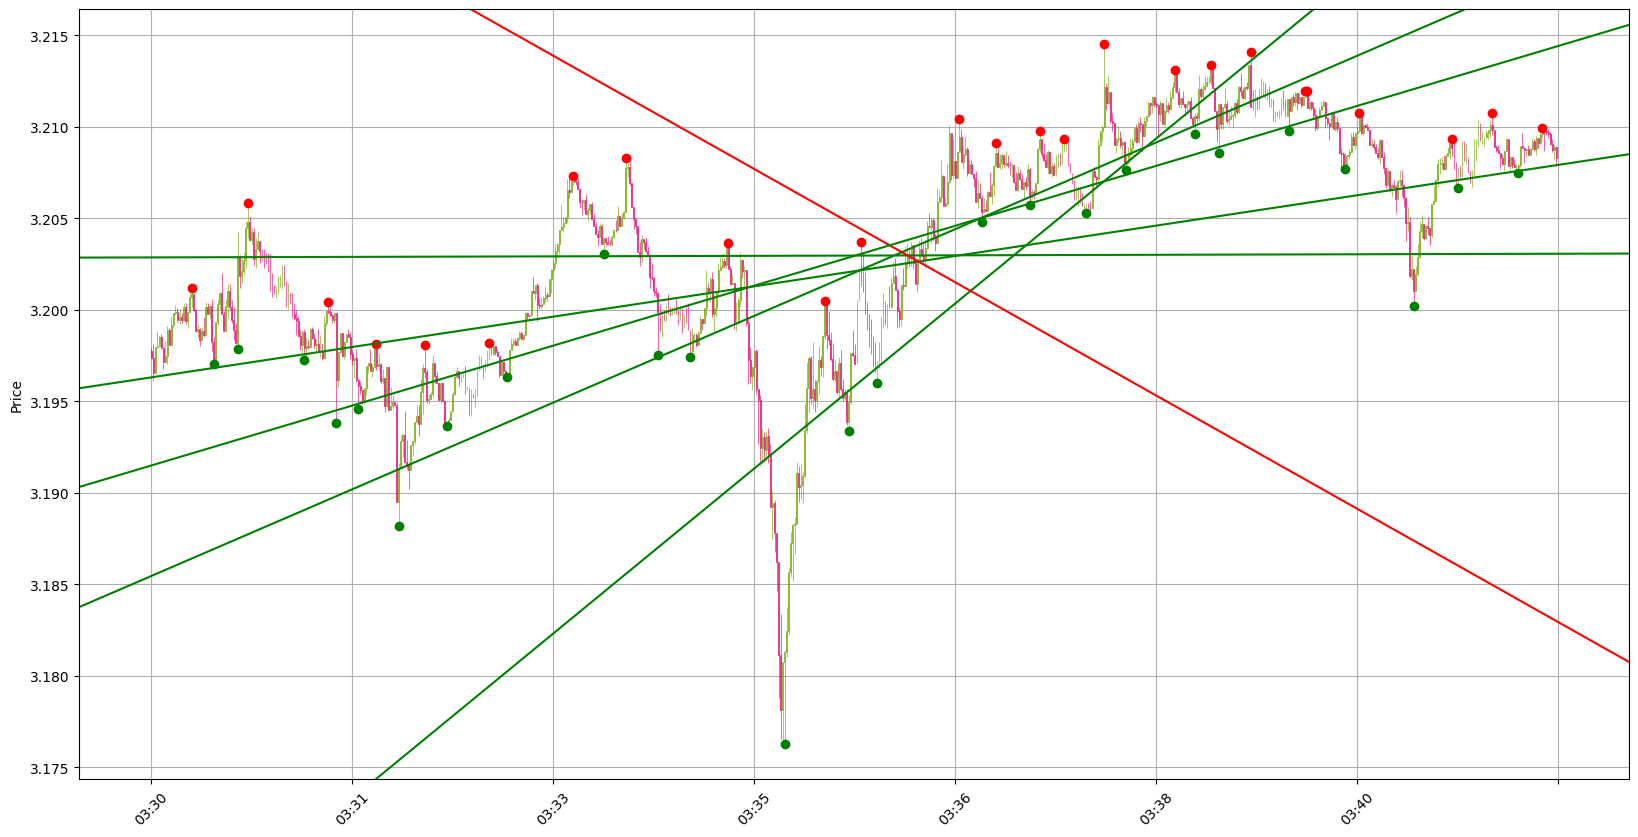

In [10]:
pdf = df.copy()
pdf = pdf.reset_index()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))

draw_candlestick_plot(ax=ax, df=pdf)
ax.plot(pdf.high[pdf.isfh], "ro")
ax.plot(pdf.low[pdf.isfl], "go")


for slope, intercept in lines:
    x = len(pdf) // 2
    xy1 = (x, slope * x + intercept)
    color = "g" if 0 < slope else "r"
    print(xy1)
    print(slope)
    print(intercept)
    ax.axline(xy1=xy1, slope=slope, color=color)
    
ax.grid()